# Protein Backbone Diffusion V1

Minimal DDPM baseline for generating padded protein backbone coordinates `(N, CA, C, O)` from noise.
This notebook keeps the starter Google Drive workflow, audits the data before training, then trains and samples a simple backbone denoiser.

## 1. Runtime and setup

This section detects the runtime, mounts Google Drive when needed, locates the repository, installs the small visualization dependency, and sets the seed/device/output directories.

In [1]:
import base64
import os
import random
import subprocess
import sys
import time
from getpass import getpass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from torch.utils.data import DataLoader

try:
    import google.colab  # type: ignore
    from google.colab import userdata  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_REMOTE_URL = os.environ.get('GITHUB_REPO_URL', 'https://github.com/mitsenkov/latent-structure-diffusion.git')
REPO_BRANCH = os.environ.get('GITHUB_REPO_BRANCH', 'main')
REPO_CLONE_DIR = Path(os.environ.get('REPO_CLONE_DIR', '/content/latent-structure-diffusion'))
REPO_DRIVE_DIR = Path(os.environ.get('REPO_DRIVE_DIR', '/content/drive/MyDrive/latent-structure-diffusion'))
DEFAULT_CATH_FOLDER_ID = os.environ.get('CATH_SHARED_FOLDER_ID', '')
LOCAL_DATA_CACHE = Path(os.environ.get('CATH_LOCAL_CACHE', '/content/cath_backbone_data'))
ALLOW_GIT_CLONE = os.environ.get('ALLOW_GIT_CLONE', '1' if IN_COLAB else '0') == '1'


def get_github_token() -> str | None:
    """Return a GitHub token from env, Colab userdata, or an interactive prompt."""
    token = os.environ.get('GITHUB_TOKEN')
    if token:
        return token.strip()
    if IN_COLAB:
        try:
            token = userdata.get('GITHUB_TOKEN')
        except Exception:  # noqa: BLE001
            token = None
        if token:
            return str(token).strip()
    if ALLOW_GIT_CLONE:
        token = getpass('Paste the GitHub token with read access to this repo: ').strip()
        if token:
            return token
    return None


def find_repo_root(start_paths: list[Path] | None = None) -> Path | None:
    """Return the repository root if a checkout is already present."""
    candidates = start_paths or [Path.cwd().resolve(), REPO_CLONE_DIR, REPO_DRIVE_DIR]
    for start in candidates:
        if not start.exists():
            continue
        for candidate in [start, *start.parents]:
            if (candidate / 'pyproject.toml').exists() and (candidate / 'src').exists():
                return candidate
    return None


def build_auth_header(token: str) -> str:
    """Build a Git basic auth header for private GitHub clone access."""
    raw = f'x-access-token:{token}'.encode('utf-8')
    encoded = base64.b64encode(raw).decode('ascii')
    return f'AUTHORIZATION: basic {encoded}'


def bootstrap_repo() -> Path:
    """Make the repo available in Colab or reuse an existing checkout."""
    existing_root = find_repo_root()
    if existing_root is not None:
      if IN_COLAB:
          token = get_github_token()
          if token:
              pull_cmd = [
                  'git',
                  '-C',
                  str(existing_root),
                  '-c',
                  f'http.extraheader={build_auth_header(token)}',
                  'pull',
                  '--ff-only',
              ]
              subprocess.run(pull_cmd, check=True, capture_output=True, text=True)
      return existing_root

    if not IN_COLAB:
        raise FileNotFoundError(
            'Could not locate the repository root. Expected a folder containing pyproject.toml and src/.'
        )

    if not ALLOW_GIT_CLONE:
        raise FileNotFoundError(
            'Could not locate a local repo checkout. In Colab, set ALLOW_GIT_CLONE=1 or define GITHUB_TOKEN.'
        )

    token = get_github_token()
    if not token:
        raise FileNotFoundError(
            'GitHub cloning was enabled, but no token was provided.'
        )

    REPO_CLONE_DIR.parent.mkdir(parents=True, exist_ok=True)
    clone_cmd = [
        'git',
        '-c',
        f'http.extraheader={build_auth_header(token)}',
        'clone',
        '--branch',
        REPO_BRANCH,
        REPO_REMOTE_URL,
        str(REPO_CLONE_DIR),
    ]
    try:
        subprocess.run(clone_cmd, check=True, capture_output=True, text=True)
    except subprocess.CalledProcessError as exc:
        stderr = (exc.stderr or '').strip()
        stdout = (exc.stdout or '').strip()
        details = '\n'.join(part for part in [stdout, stderr] if part)
        raise RuntimeError(
            'GitHub clone failed in this Colab runtime. The token may be missing, invalid, or lack repo read access. '            f'Command: git clone --branch {REPO_BRANCH} {REPO_REMOTE_URL} {REPO_CLONE_DIR}\n{details}'
        ) from exc
    return REPO_CLONE_DIR


def ensure_gdown_installed() -> None:
    """Install gdown on demand."""
    try:
        import gdown  # type: ignore  # noqa: F401
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gdown'])


def resolve_data_dir() -> Path:
    """Resolve the dataset directory without requiring a Drive mount."""
    env_dir = os.environ.get('CATH_DATA_DIR')
    if env_dir:
        candidate = Path(env_dir)
        if (candidate / 'chain_set.jsonl').exists() and (candidate / 'chain_set_splits.json').exists():
            return candidate

    local_candidate = LOCAL_DATA_CACHE
    if (local_candidate / 'chain_set.jsonl').exists() and (local_candidate / 'chain_set_splits.json').exists():
        return local_candidate

    if IN_COLAB:
        ensure_gdown_installed()
        import gdown  # type: ignore

        local_candidate.mkdir(parents=True, exist_ok=True)
        url = f'https://drive.google.com/drive/folders/{DEFAULT_CATH_FOLDER_ID}'
        gdown.download_folder(url=url, output=str(local_candidate), quiet=False, use_cookies=False)
        if (local_candidate / 'chain_set.jsonl').exists() and (local_candidate / 'chain_set_splits.json').exists():
            return local_candidate

    raise FileNotFoundError(
        'Could not resolve the CATH dataset directory. Set CATH_DATA_DIR to a local path with chain_set.jsonl '
        'and chain_set_splits.json, or allow the notebook to download the public shared folder.'
    )


REPO_ROOT = bootstrap_repo()
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = resolve_data_dir()

ARTIFACT_BASE_DIR = Path(os.environ.get('BACKBONE_DIFFUSION_ARTIFACT_BASE_DIR', str(REPO_ROOT / 'results' / 'v1_backbone_diffusion')))
ARTIFACT_RUN_NAME = os.environ.get('BACKBONE_DIFFUSION_RUN_NAME', 'v1')
ARTIFACT_DIR = ARTIFACT_BASE_DIR / ARTIFACT_RUN_NAME
FIGURE_DIR = ARTIFACT_DIR / 'figures'
TABLE_DIR = ARTIFACT_DIR / 'tables'
CHECKPOINT_DIR = ARTIFACT_DIR / 'checkpoints'
for directory in [FIGURE_DIR, TABLE_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

def save_table_artifact(frame: pd.DataFrame, name: str, *, drop_columns: list[str] | None = None) -> dict[str, Path]:
    """Save a dataframe as CSV and Parquet under the run's tables directory."""
    export_frame = frame.drop(columns=[column for column in (drop_columns or []) if column in frame.columns]).copy()
    csv_path = TABLE_DIR / f'{name}.csv'
    parquet_path = TABLE_DIR / f'{name}.parquet'
    export_frame.to_csv(csv_path, index=False)
    try:
        export_frame.to_parquet(parquet_path, index=False)
    except Exception as exc:  # noqa: BLE001
        print(f'Could not write Parquet for {name}: {exc}')
    return {'csv': csv_path, 'parquet': parquet_path}

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    device_name = torch.cuda.get_device_name(0)
else:
    device_name = 'CPU'

try:
    import py3Dmol  # type: ignore
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'py3Dmol'])
    import py3Dmol  # type: ignore

try:
    import pyarrow  # type: ignore  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyarrow'])

from latent_structure_generation.backbone_diffusion import (
    BACKBONE_ATOMS,
    BackboneDataset,
    BackboneDenoiser,
    BackboneNormalizationStats,
    apply_coordinate_normalisation,
    backbone_coords_to_protein,
    backbone_structure_summary,
    build_normalization_stats_from_dataframe,
    build_overlapping_backbone_chunks,
    collate_backbone_examples,
    centre_coordinates,
    create_noise_schedule,
    extract_backbone_from_coords_dict,
    flatten_backbone,
    invert_coordinate_normalisation,
    masked_coordinate_rmse,
    masked_noise_mse,
    pad_or_crop_backbone,
    predict_x0,
    q_sample,
    sample_backbone,
    sample_timesteps,
    structure_validity_report,
    to_pdb,
    unflatten_backbone,
)
from latent_structure_generation.plots import plot_ca_trace

print(f'Repository root: {REPO_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Artifacts: {ARTIFACT_DIR}')
print(f'Seed: {SEED}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'Selected device: {device}')
print(f'Device name: {device_name}')
print(f'GitHub clone enabled: {ALLOW_GIT_CLONE}')
print(f'GitHub token present: {bool(os.environ.get("GITHUB_TOKEN") or (IN_COLAB and "GITHUB_TOKEN" in getattr(userdata, "keys", lambda: [])()))}')


Repository root: /content/latent-structure-diffusion
Data directory: /content/cath_backbone_data
Artifacts: /content/latent-structure-diffusion/results/v1_backbone_diffusion
Seed: 42
CUDA available: True
Selected device: cuda
Device name: NVIDIA L4
GitHub clone enabled: True
GitHub token present: False


## 2. Load the starter CATH tables

This reuses the provided Google Drive layout from the starter notebook. The split names are canonicalized to `train`, `validation`, and `test` so later code does not depend on `val` vs `validation` naming drift.

In [2]:
chain_set_path = DATA_DIR / 'chain_set.jsonl'
split_path = DATA_DIR / 'chain_set_splits.json'

print(f'Reading {chain_set_path}')
df = pd.read_json(chain_set_path, lines=True)
print(f'Reading {split_path}')
chain_splits = pd.read_json(split_path, lines=True)


def canonical_split_name(name: str) -> str:
    """Map split labels to the canonical notebook names."""
    return {'val': 'validation', 'validation': 'validation', 'train': 'train', 'test': 'test'}.get(name, name)


split_lookup: dict[str, str] = {}

# Preserve the true train/validation/test buckets first.
for column in ['train', 'validation', 'test']:
    if column not in chain_splits.columns:
        continue
    canonical = canonical_split_name(column)
    values = chain_splits[column].iloc[0]
    for record_name in values:
        split_lookup.setdefault(record_name, canonical)

# cath_nodes is auxiliary metadata; use it only for records not already assigned.
if 'cath_nodes' in chain_splits.columns:
    cath_nodes = chain_splits['cath_nodes'].iloc[0]
    for record_name in cath_nodes.keys():
        split_lookup.setdefault(record_name, 'cath_nodes')

df['split'] = df['name'].map(split_lookup).fillna('unknown')
df['split'] = df['split'].map(canonical_split_name)

available_splits = sorted(df['split'].dropna().unique().tolist())
print('Available splits:', available_splits)
print('Split counts:')
print(df['split'].value_counts(dropna=False).sort_index())
print('Columns:', list(df.columns))
print('Example row keys:', list(df.iloc[0].index))

save_table_artifact(df, 'raw_chain_manifest', drop_columns=['coords'])

Reading /content/cath_backbone_data/chain_set.jsonl
Reading /content/cath_backbone_data/chain_set_splits.json
Available splits: ['cath_nodes', 'test', 'train', 'unknown', 'validation']
Split counts:
split
cath_nodes     1820
test           1120
train         18024
unknown          96
validation      608
Name: count, dtype: int64
Columns: ['seq', 'coords', 'num_chains', 'name', 'CATH', 'split']
Example row keys: ['seq', 'coords', 'num_chains', 'name', 'CATH', 'split']


## 3. Data audit before training

This is the required review phase. It checks shapes, masks, invalid values, real lengths, truncation, coordinate ranges, backbone bond lengths, and a few visual examples before any training code runs.

In [ ]:
from collections import defaultdict


def move_batch_to_device(batch: dict[str, object], target_device: torch.device) -> dict[str, object]:
    """Move tensor values in a batch to the selected device."""
    moved: dict[str, object] = {}
    for key, value in batch.items():
        moved[key] = value.to(target_device) if torch.is_tensor(value) else value
    return moved


def audit_dataframe(split_df: pd.DataFrame, split_name: str, max_length: int) -> pd.DataFrame:
    """Audit one split and return a per-example summary table."""
    rows: list[dict[str, object]] = []
    for _, row in split_df.reset_index(drop=True).iterrows():
        record_id = row['name']
        try:
            coords, residue_mask = extract_backbone_from_coords_dict(row['coords'])
            raw_length = int(coords.shape[0])
            real_length = int(residue_mask.sum())
            coords_fixed, mask_fixed, truncated = pad_or_crop_backbone(coords, residue_mask, max_length)
            coords_t = torch.tensor(coords_fixed, dtype=torch.float32)
            mask_t = torch.tensor(mask_fixed.astype(np.float32), dtype=torch.float32)
            has_nan = bool(np.isnan(coords_fixed).any())
            has_inf = bool(np.isinf(coords_fixed).any())
            zero_real_residues = int(((np.abs(coords_fixed).sum(axis=(1, 2)) == 0.0) & mask_fixed).sum())
            summary = backbone_structure_summary(coords_t, mask_t)
            rows.append(
                {
                    'record_id': record_id,
                    'split': split_name,
                    'raw_length': raw_length,
                    'real_length': real_length,
                    'padded_length': int(mask_fixed.shape[0]),
                    'truncated': bool(truncated),
                    'has_nan': has_nan,
                    'has_inf': has_inf,
                    'zero_real_residues': zero_real_residues,
                    'keep_example': bool(real_length > 0 and not has_nan and not has_inf),
                    **summary,
                }
            )
        except Exception as exc:  # noqa: BLE001
            rows.append(
                {
                    'record_id': record_id,
                    'split': split_name,
                    'raw_length': np.nan,
                    'real_length': 0,
                    'padded_length': max_length,
                    'truncated': False,
                    'has_nan': True,
                    'has_inf': True,
                    'zero_real_residues': 0,
                    'keep_example': False,
                    'audit_error': str(exc),
                    'n_residues': 0,
                    'mean_adjacent_ca': np.nan,
                    'fraction_adjacent_ca_in_band': np.nan,
                    'mean_n_ca': np.nan,
                    'mean_ca_c': np.nan,
                    'mean_c_o': np.nan,
                    'mean_c_n': np.nan,
                    'radius_of_gyration': np.nan,
                }
            )
    return pd.DataFrame(rows)


def summarize_lengths(audit_df: pd.DataFrame) -> pd.DataFrame:
    """Summarize real lengths, padding, and truncation for one split."""
    if audit_df.empty:
        return pd.DataFrame([
            {
                'split': 'unknown',
                'n_examples': 0,
                'min_real_length': np.nan,
                'median_real_length': np.nan,
                'max_real_length': np.nan,
                'mean_real_length': np.nan,
                'mean_padding_fraction': np.nan,
                'truncated_fraction': np.nan,
            }
        ])

    if 'keep_example' not in audit_df.columns:
        valid = audit_df.copy()
    else:
        valid = audit_df[audit_df['keep_example'].fillna(False)].copy()
    if valid.empty:
        split_name = audit_df['split'].iloc[0] if 'split' in audit_df.columns and len(audit_df) else 'unknown'
        return pd.DataFrame([
            {
                'split': split_name,
                'n_examples': 0,
                'min_real_length': np.nan,
                'median_real_length': np.nan,
                'max_real_length': np.nan,
                'mean_real_length': np.nan,
                'mean_padding_fraction': np.nan,
                'truncated_fraction': np.nan,
            }
        ])

    lengths = valid['real_length'].astype(int)
    padded_fraction = 1.0 - (lengths / valid['padded_length'].astype(int))
    return pd.DataFrame(
        [
            {
                'split': valid['split'].iloc[0],
                'n_examples': int(len(valid)),
                'min_real_length': int(lengths.min()),
                'median_real_length': float(lengths.median()),
                'max_real_length': int(lengths.max()),
                'mean_real_length': float(lengths.mean()),
                'mean_padding_fraction': float(padded_fraction.mean()),
                'truncated_fraction': float(valid['truncated'].mean()),
            }
        ]
    )


def coordinate_moments(split_df: pd.DataFrame, max_length: int) -> dict[str, np.ndarray | float]:
    """Compute mean/std/RMS statistics over real atom coordinates only."""
    sum_xyz = np.zeros(3, dtype=np.float64)
    sum_sq_xyz = np.zeros(3, dtype=np.float64)
    count = 0
    rg_values: list[float] = []
    for _, row in split_df.reset_index(drop=True).iterrows():
        coords, residue_mask = extract_backbone_from_coords_dict(row['coords'])
        if residue_mask.sum() == 0:
            continue
        coords_fixed, mask_fixed, _ = pad_or_crop_backbone(coords, residue_mask, max_length)
        coords_t = torch.tensor(coords_fixed, dtype=torch.float32)
        mask_t = torch.tensor(mask_fixed.astype(np.float32), dtype=torch.float32)
        centred = centre_coordinates(coords_t.unsqueeze(0), mask_t.unsqueeze(0))[0]
        real = centred[mask_t.bool()].reshape(-1, 3)
        sum_xyz += real.sum(dim=0).cpu().numpy()
        sum_sq_xyz += (real.pow(2)).sum(dim=0).cpu().numpy()
        count += int(real.shape[0])
        rg_values.append(float(backbone_structure_summary(coords_t, mask_t)['radius_of_gyration']))
    mean = sum_xyz / max(count, 1)
    var = sum_sq_xyz / max(count, 1) - mean**2
    std = np.sqrt(np.clip(var, 1e-6, None))
    return {'mean': mean, 'std': std, 'rms': float(np.sqrt(np.mean(sum_sq_xyz / max(count, 1)))), 'count': count, 'radius_of_gyration_mean': float(np.mean(rg_values)) if rg_values else float('nan')}


MAX_SEQ_LENGTH = 256
train_audit = audit_dataframe(df[df['split'] == 'train'], 'train', MAX_SEQ_LENGTH)
val_audit = audit_dataframe(df[df['split'] == 'validation'], 'validation', MAX_SEQ_LENGTH)
test_audit = audit_dataframe(df[df['split'] == 'test'], 'test', MAX_SEQ_LENGTH)

audit_df = pd.concat([train_audit, val_audit, test_audit], ignore_index=True)

length_summary_df = pd.concat(
    [summarize_lengths(train_audit), summarize_lengths(val_audit), summarize_lengths(test_audit)],
    ignore_index=True,
)

print('Audit summary by split:')
display(length_summary_df)

print('Invalid / filtered examples by split:')
filter_summary = (
    audit_df.groupby('split', as_index=False)
    .agg(total_examples=('record_id', 'count'), kept_examples=('keep_example', 'sum'), invalid_examples=('keep_example', lambda s: int((~s).sum())), truncated_examples=('truncated', 'sum'))
)
filter_summary['filtered_out'] = filter_summary['total_examples'] - filter_summary['kept_examples']
display(filter_summary)

print('Coordinate and structure summary on the training split:')
train_moments = coordinate_moments(df[df['split'] == 'train'], MAX_SEQ_LENGTH)
print(train_moments)

print('Head of the audit table:')
display(audit_df.head(8))

save_table_artifact(train_audit, 'train_audit')
save_table_artifact(val_audit, 'validation_audit')
save_table_artifact(test_audit, 'test_audit')
save_table_artifact(audit_df, 'audit_table')
save_table_artifact(length_summary_df, 'length_summary')
save_table_artifact(filter_summary, 'filter_summary')

print('Shape checks:')
print('coords expected shape: (B, L, 4, 3)')
print('mask expected shape: (B, L)')
print('backbone atom axis:', BACKBONE_ATOMS)
print('training split examples kept:', int(train_audit['keep_example'].sum()))
print('validation split examples kept:', int(val_audit['keep_example'].sum()))
print('test split examples kept:', int(test_audit['keep_example'].sum()))

Audit summary by split:


,split,n_examples,min_real_length,median_real_length,max_real_length,mean_real_length,mean_padding_fraction,truncated_fraction
0,train,18024,39,204.0,500,218.666611,0.145834,0.411895
1,validation,608,40,146.0,475,174.185855,0.319587,0.217105
2,test,1120,40,138.0,497,162.196429,0.366420,0.167857


Invalid / filtered examples by split:


,split,total_examples,kept_examples,invalid_examples,truncated_examples,filtered_out
0,test,1120,1120,0,188,0
1,train,18024,18024,0,7424,0
2,validation,608,608,0,132,0


### What the audit established

The audit keeps padded positions, drops only examples with no valid backbone residues, and reports the amount of truncation caused by fixed-length batching. The same summary tables also give the train-only statistics needed for normalization. Long training chains are then expanded into overlapping fixed-length chunks so we stop throwing away so much of each protein.

In [4]:
# Build chain-level filtered split tables first.
train_chain_df = df[df['split'] == 'train'].reset_index(drop=True)
validation_chain_df = df[df['split'] == 'validation'].reset_index(drop=True)
test_chain_df = df[df['split'] == 'test'].reset_index(drop=True)

train_df = train_chain_df[train_audit['keep_example'].values].reset_index(drop=True)
validation_df = validation_chain_df[val_audit['keep_example'].values].reset_index(drop=True)
test_df = test_chain_df[test_audit['keep_example'].values].reset_index(drop=True)

# Expand long training chains into overlapping 256-residue windows.
TRAIN_CHUNK_STRIDE = 128
train_chunked_df = build_overlapping_backbone_chunks(
    train_df,
    split='train',
    max_length=MAX_SEQ_LENGTH,
    stride=TRAIN_CHUNK_STRIDE,
    record_id_column='name',
)

print('Filtered split sizes:')
print('train:', len(train_df))
print('validation:', len(validation_df))
print('test:', len(test_df))
print('train chunks:', len(train_chunked_df))
print('unique train parent chains:', train_chunked_df['parent_chain_id'].nunique())
print('training chunk stride:', TRAIN_CHUNK_STRIDE)
chunk_count_summary = train_chunked_df.groupby('parent_chain_id').size()
print('chunk count per parent chain: min', int(chunk_count_summary.min()), 'median', float(chunk_count_summary.median()), 'max', int(chunk_count_summary.max()))
print('chunk length range:', int(train_chunked_df['chunk_length'].min()), 'to', int(train_chunked_df['chunk_length'].max()))
chunk_count_summary_df = chunk_count_summary.rename_axis('parent_chain_id').reset_index(name='chunk_count')

save_table_artifact(train_df, 'train_chains_manifest', drop_columns=['coords'])
save_table_artifact(validation_df, 'validation_chains_manifest', drop_columns=['coords'])
save_table_artifact(test_df, 'test_chains_manifest', drop_columns=['coords'])
save_table_artifact(train_chunked_df, 'train_chunked_manifest', drop_columns=['coords'])
save_table_artifact(chunk_count_summary_df, 'train_chunk_counts')

train_dataset = BackboneDataset(train_chunked_df, split='train', max_length=MAX_SEQ_LENGTH, record_id_column='chunk_id')
validation_dataset = BackboneDataset(validation_df, split='validation', max_length=MAX_SEQ_LENGTH)
test_dataset = BackboneDataset(test_df, split='test', max_length=MAX_SEQ_LENGTH)

BATCH_SIZE = 32
NUM_WORKERS = 2 if IN_COLAB else 0
PIN_MEMORY = device.type == 'cuda'

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_backbone_examples,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_backbone_examples,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_backbone_examples,
)

example_batch = next(iter(train_loader))
print('Example batch keys:', list(example_batch.keys()))
print('coords shape:', tuple(example_batch['coords'].shape), 'dtype:', example_batch['coords'].dtype, 'device:', example_batch['coords'].device)
print('mask shape:', tuple(example_batch['mask'].shape), 'dtype:', example_batch['mask'].dtype, 'device:', example_batch['mask'].device)
print('lengths shape:', tuple(example_batch['length'].shape))
print('real_length shape:', tuple(example_batch['real_length'].shape))
print('truncated shape:', tuple(example_batch['truncated'].shape))
print('first record ids:', example_batch['record_id'][:3])
print('first parent chain ids:', example_batch['parent_chain_id'][:3])
print('first chunk ids:', example_batch['chunk_id'][:3])

Filtered split sizes:
train: 18024
validation: 608
test: 1120
train chunks: 27706
unique train parent chains: 18024
training chunk stride: 128
chunk count per parent chain: min 1 median 1.0 max 3
chunk length range: 40 to 256
Example batch keys: ['record_id', 'split', 'coords', 'mask', 'length', 'real_length', 'truncated', 'parent_chain_id', 'chunk_id', 'chunk_index', 'chunk_start', 'chunk_end', 'chunk_length', 'chunk_count', 'source_length']
coords shape: (32, 256, 4, 3) dtype: torch.float32 device: cpu
mask shape: (32, 256) dtype: torch.float32 device: cpu
lengths shape: (32,)
real_length shape: (32,)
truncated shape: (32,)
first record ids: ['3m1r.A__chunk001_0066_0322', '2lcc.A__chunk000_0000_0076', '1iio.A__chunk000_0000_0084']
first parent chain ids: ['3m1r.A', '2lcc.A', '1iio.A']
first chunk ids: ['3m1r.A__chunk001_0066_0322', '2lcc.A__chunk000_0000_0076', '1iio.A__chunk000_0000_0084']


## 4. Visual sanity checks on real data

This shows a few training examples before any normalization or diffusion is applied. The point is to confirm that the backbone traces and masks line up with the expected protein geometry.

Real example 0: 3m1r.A__chunk001_0066_0322
{'n_residues': 256.0, 'mean_adjacent_ca': 4.3893208503723145, 'fraction_adjacent_ca_in_band': 0.9803921580314636, 'mean_n_ca': 1.4416983127593994, 'mean_ca_c': 1.5079243183135986, 'mean_c_o': 1.2156610488891602, 'mean_c_n': 1.9492661952972412, 'radius_of_gyration': 18.1343994140625}


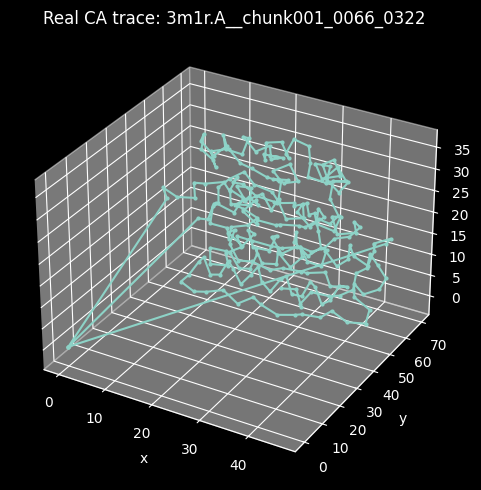

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Real example 1: 2lcc.A__chunk000_0000_0076
{'n_residues': 76.0, 'mean_adjacent_ca': 3.7634761333465576, 'fraction_adjacent_ca_in_band': 1.0, 'mean_n_ca': 1.4420362710952759, 'mean_ca_c': 1.5160902738571167, 'mean_c_o': 1.234939694404602, 'mean_c_n': 1.3061072826385498, 'radius_of_gyration': 13.3764066696167}


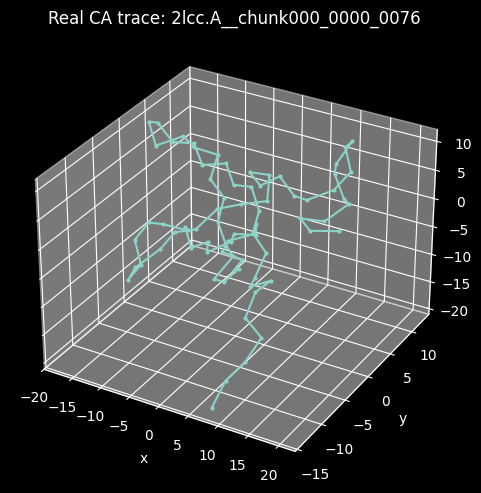

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
def plot_ca_trace_from_batch(coords: torch.Tensor, mask: torch.Tensor, title: str):
    """Plot a CA trace using the existing plotting helper."""
    ca = coords[mask.bool(), 1, :].detach().cpu().numpy()
    fig, ax = plot_ca_trace(ca, title=title)
    plt.show()
    return fig, ax


def render_backbone_example(coords: torch.Tensor, mask: torch.Tensor, title: str):
    """Render one backbone structure as a PDB-backed py3Dmol viewer."""
    protein = backbone_coords_to_protein(coords, mask)
    pdb_str = to_pdb(protein)
    view = py3Dmol.view(width=700, height=500)
    view.addModel(pdb_str, 'pdb')
    view.setStyle({'cartoon': {'color': 'spectrum'}})
    view.zoomTo()
    view.show()
    return view


for index in range(min(2, example_batch['coords'].shape[0])):
    real_coords = example_batch['coords'][index]
    real_mask = example_batch['mask'][index]
    print(f'Real example {index}:', example_batch['record_id'][index])
    print(backbone_structure_summary(real_coords, real_mask))
    plot_ca_trace_from_batch(real_coords, real_mask.bool(), title=f"Real CA trace: {example_batch['record_id'][index]}")
    render_backbone_example(real_coords, real_mask, title=f"Real backbone: {example_batch['record_id'][index]}")

## 5. Preprocessing and train-only normalization

The model sees centered backbone coordinates that are standardized with statistics computed from the training split only. This cell also checks the flatten / unflatten / inverse-transform path before training starts.

In [6]:
normalization_stats = build_normalization_stats_from_dataframe(train_df)
print('Normalization mean:', normalization_stats.mean)
print('Normalization std:', normalization_stats.std)

smoke_batch = next(iter(train_loader))
coords = smoke_batch['coords']
mask = smoke_batch['mask']
coords_centered = centre_coordinates(coords, mask)
coords_norm = apply_coordinate_normalisation(coords_centered, mask, normalization_stats)
coords_flat = flatten_backbone(coords_norm)
coords_roundtrip = unflatten_backbone(coords_flat)
coords_denorm = invert_coordinate_normalisation(coords_roundtrip, normalization_stats)

print('coords_centered:', tuple(coords_centered.shape))
print('coords_norm:', tuple(coords_norm.shape))
print('coords_flat:', tuple(coords_flat.shape))
print('coords_roundtrip:', tuple(coords_roundtrip.shape))
print('coords_denorm:', tuple(coords_denorm.shape))
print('max inverse diff:', float((coords_denorm - coords_centered).abs().max().item()))
print('smoke-test mask sum:', float(mask.sum().item()))

Normalization mean: tensor([3.9541e-09, 6.3693e-09, 1.4911e-08])
Normalization std: tensor([11.5103, 11.4502, 12.1258])
coords_centered: (32, 256, 4, 3)
coords_norm: (32, 256, 4, 3)
coords_flat: (32, 256, 12)
coords_roundtrip: (32, 256, 4, 3)
coords_denorm: (32, 256, 4, 3)
max inverse diff: 1.9073486328125e-06
smoke-test mask sum: 7389.0


## 6. Diffusion utilities and model

This is the actual V1 baseline: a linear DDPM noise schedule, a simple 1D residual denoiser, and a masked noise-prediction objective.

In [7]:
TIMESTEPS = 100
noise_schedule = create_noise_schedule(TIMESTEPS, device=device)

model = BackboneDenoiser(max_length=MAX_SEQ_LENGTH, hidden_dim=256, num_layers=4, time_embedding_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)
print('Schedule keys:', list(noise_schedule.keys()))
print('Schedule shapes:')
for key, value in noise_schedule.items():
    print(key, tuple(value.shape), value.device)

with torch.no_grad():
    demo_coords = coords_norm.to(device)
    demo_mask = mask.to(device)
    demo_t = sample_timesteps(demo_coords.shape[0], TIMESTEPS, device)
    demo_noise = torch.randn_like(flatten_backbone(demo_coords))
    demo_x0 = flatten_backbone(demo_coords)
    demo_xt = q_sample(demo_x0, demo_t, demo_noise, noise_schedule['alpha_bars'])
    demo_pred = model(demo_xt, demo_t, demo_mask)

print('x0 shape:', tuple(demo_x0.shape))
print('xt shape:', tuple(demo_xt.shape))
print('pred shape:', tuple(demo_pred.shape))
assert demo_pred.shape == demo_x0.shape

BackboneDenoiser(
  (input_proj): Linear(in_features=13, out_features=256, bias=True)
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (pos_emb): Embedding(256, 256)
  (blocks): ModuleList(
    (0-3): 4 x ResidualConvBlock(
      (block): Sequential(
        (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): GroupNorm(8, 256, eps=1e-05, affine=True)
        (2): SiLU()
        (3): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
        (4): GroupNorm(8, 256, eps=1e-05, affine=True)
      )
      (activation): SiLU()
    )
  )
  (output_proj): Linear(in_features=256, out_features=12, bias=True)
)
Schedule keys: ['betas', 'alphas', 'alpha_bars', 'alpha_bars_prev', 'posterior_variance']
Schedule shapes:
betas (101,) cuda:0
alphas (101,) cuda:0
alpha_bars (101,) cuda:0
alpha_bars_prev (101,) cuda:0
posterior_variance (101,) c

## 7. Training, validation, and test evaluation

The loop tracks DDPM noise loss and an auxiliary x0 reconstruction RMSE. Validation and test are strictly masked and use the same train-derived normalization.

In [ ]:
def prepare_batch_for_diffusion(batch: dict[str, object], target_device: torch.device, stats: BackboneNormalizationStats) -> tuple[torch.Tensor, torch.Tensor]:
    """Move a batch to device and return normalized flattened coords plus the mask."""
    batch = move_batch_to_device(batch, target_device)
    coords = batch['coords']
    mask = batch['mask']
    coords_centered = centre_coordinates(coords, mask)
    coords_norm = apply_coordinate_normalisation(coords_centered, mask, stats)
    coords_flat = flatten_backbone(coords_norm)
    return coords_flat, mask


def run_epoch(
    model: torch.nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer | None,
    stats: BackboneNormalizationStats,
    schedule: dict[str, torch.Tensor],
    target_device: torch.device,
) -> dict[str, float]:
    """Run one training or evaluation epoch."""
    is_training = optimizer is not None
    model.train(is_training)
    totals = defaultdict(float)
    n_batches = 0

    for batch in loader:
        coords_flat, mask = prepare_batch_for_diffusion(batch, target_device, stats)
        t = sample_timesteps(coords_flat.shape[0], TIMESTEPS, target_device)
        noise = torch.randn_like(coords_flat)
        x_t = q_sample(coords_flat, t, noise, schedule['alpha_bars'])

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            pred_noise = model(x_t, t, mask)
            loss = masked_noise_mse(pred_noise, noise, mask)
            x0_pred = predict_x0(x_t, t, pred_noise, schedule['alpha_bars'])
            recon_rmse = masked_coordinate_rmse(x0_pred, coords_flat, mask)
            if is_training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        totals['loss'] += float(loss.detach().cpu())
        totals['x0_rmse'] += float(recon_rmse.detach().cpu())
        n_batches += 1

    return {key: value / max(n_batches, 1) for key, value in totals.items()}


EPOCHS = 5
history: list[dict[str, float]] = []
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    train_metrics = run_epoch(model, train_loader, optimizer, normalization_stats, noise_schedule, device)
    val_metrics = run_epoch(model, validation_loader, None, normalization_stats, noise_schedule, device)
    test_metrics = run_epoch(model, test_loader, None, normalization_stats, noise_schedule, device)

    row = {
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'train_x0_rmse': train_metrics['x0_rmse'],
        'validation_loss': val_metrics['loss'],
        'validation_x0_rmse': val_metrics['x0_rmse'],
        'test_loss': test_metrics['loss'],
        'test_x0_rmse': test_metrics['x0_rmse'],
        'lr': optimizer.param_groups[0]['lr'],
        'epoch_seconds': time.time() - start_time,
    }
    history.append(row)
    if row['validation_loss'] < best_val_loss:
        best_val_loss = row['validation_loss']
        torch.save(
            {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'normalization_mean': normalization_stats.mean,
                'normalization_std': normalization_stats.std,
                'timesteps': TIMESTEPS,
                'max_length': MAX_SEQ_LENGTH,
                'batch_size': BATCH_SIZE,
                'seed': SEED,
            },
            CHECKPOINT_DIR / 'best_backbone_diffusion.pt',
        )
    print(
        f"Epoch {epoch:02d} | train loss {row['train_loss']:.5f} | val loss {row['validation_loss']:.5f} | "
        f"test loss {row['test_loss']:.5f} | val x0 RMSE {row['validation_x0_rmse']:.4f} | "
        f"{row['epoch_seconds']:.1f}s"
    )

history_df = pd.DataFrame(history)
display(history_df)
save_table_artifact(history_df, 'backbone_diffusion_history')

Epoch 01 | train loss 0.09617 | val loss 0.09021 | test loss 0.09478 | val x0 RMSE 0.1635 | 13.4s
Epoch 02 | train loss 0.09313 | val loss 0.09654 | test loss 0.09830 | val x0 RMSE 0.1578 | 13.4s
Epoch 03 | train loss 0.09216 | val loss 0.09572 | test loss 0.09298 | val x0 RMSE 0.1564 | 13.9s
Epoch 04 | train loss 0.09084 | val loss 0.08990 | test loss 0.09159 | val x0 RMSE 0.1639 | 13.9s
Epoch 05 | train loss 0.08859 | val loss 0.08741 | test loss 0.08781 | val x0 RMSE 0.1592 | 13.3s
Epoch 06 | train loss 0.08696 | val loss 0.09867 | test loss 0.09488 | val x0 RMSE 0.1606 | 13.8s
Epoch 07 | train loss 0.08626 | val loss 0.08278 | test loss 0.08672 | val x0 RMSE 0.1613 | 13.6s
Epoch 08 | train loss 0.08576 | val loss 0.08986 | test loss 0.09267 | val x0 RMSE 0.1584 | 13.5s
Epoch 09 | train loss 0.08524 | val loss 0.08368 | test loss 0.08266 | val x0 RMSE 0.1591 | 13.2s
Epoch 10 | train loss 0.08460 | val loss 0.08662 | test loss 0.08131 | val x0 RMSE 0.1546 | 13.2s
Epoch 11 | train los

In [1]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_df['epoch'], history_df['train_loss'], label='Train noise loss')
ax.plot(history_df['epoch'], history_df['validation_loss'], label='Validation noise loss')
ax.plot(history_df['epoch'], history_df['test_loss'], label='Test noise loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Masked MSE')
ax.set_title('Backbone diffusion training curves')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'backbone_diffusion_losses.png', dpi=150)
plt.show()

NameError: name 'plt' is not defined

## 8. Sampling and evaluation

This samples backbones from Gaussian noise, then denormalizes them back into coordinate space for structural evaluation and visualization.

In [10]:
model.eval()
with torch.no_grad():
    eval_batch = next(iter(validation_loader))
    sample_mask = eval_batch['mask'][:4].to(device)
    sampled_flat = sample_backbone(
        model,
        noise_schedule,
        shape=(sample_mask.shape[0], MAX_SEQ_LENGTH, 12),
        mask=sample_mask,
        device=device,
    )
    sampled_coords_norm = unflatten_backbone(sampled_flat)
    sampled_coords = invert_coordinate_normalisation(sampled_coords_norm, normalization_stats)

    real_coords = eval_batch['coords'][:4]
    real_mask = eval_batch['mask'][:4]

real_rows = []
generated_rows = []
for index in range(sampled_coords.shape[0]):
    real_rows.append({'kind': 'real', 'index': index, **backbone_structure_summary(real_coords[index], real_mask[index])})
    generated_rows.append({'kind': 'generated', 'index': index, **backbone_structure_summary(sampled_coords[index].cpu(), sample_mask[index].cpu())})

real_eval_df = pd.DataFrame(real_rows)
generated_eval_df = pd.DataFrame(generated_rows)

display(real_eval_df)
display(generated_eval_df)

comparison_df = pd.concat([real_eval_df, generated_eval_df], ignore_index=True)
comparison_summary = comparison_df.groupby('kind', as_index=False).mean(numeric_only=True)
display(comparison_summary)
save_table_artifact(real_eval_df, 'real_eval_metrics')
save_table_artifact(generated_eval_df, 'generated_eval_metrics')
save_table_artifact(comparison_df, 'real_vs_generated_summary')
save_table_artifact(comparison_summary, 'real_vs_generated_summary_mean')

,kind,index,n_residues,mean_adjacent_ca,fraction_adjacent_ca_in_band,mean_n_ca,mean_ca_c,mean_c_o,mean_c_n,radius_of_gyration
0,real,0,171.0,3.805476,0.994012,1.460498,1.527345,1.232196,1.327362,16.227869
1,real,1,63.0,3.814094,1.000000,1.460700,1.528333,1.234096,1.333291,16.453768
2,real,2,180.0,3.805939,1.000000,1.458334,1.522972,1.228173,1.329856,16.873392
3,real,3,256.0,3.826390,1.000000,1.457568,1.525439,1.230243,1.332404,18.050728


,kind,index,n_residues,mean_adjacent_ca,fraction_adjacent_ca_in_band,mean_n_ca,mean_ca_c,mean_c_o,mean_c_n,radius_of_gyration
0,generated,0,171.0,3.197740,0.257485,1.220692,1.178554,1.090613,1.517975,7.247418
1,generated,1,63.0,3.442297,0.338710,1.319266,1.415762,0.999922,1.254734,6.665573
2,generated,2,180.0,3.095869,0.242938,1.242124,1.296598,0.976211,1.197284,6.961609
3,generated,3,256.0,2.922557,0.250980,1.130339,1.170037,0.933152,1.108950,6.912992


,kind,index,n_residues,mean_adjacent_ca,fraction_adjacent_ca_in_band,mean_n_ca,mean_ca_c,mean_c_o,mean_c_n,radius_of_gyration
0,generated,1.5,167.5,3.164616,0.272528,1.228105,1.265237,0.999975,1.269736,6.946898
1,real,1.5,167.5,3.812975,0.998503,1.459275,1.526022,1.231177,1.330728,16.901439


Generated example 0
{'n_residues': 171.0, 'mean_adjacent_ca': 3.197739601135254, 'fraction_adjacent_ca_in_band': 0.257485032081604, 'mean_n_ca': 1.2206923961639404, 'mean_ca_c': 1.178553581237793, 'mean_c_o': 1.0906134843826294, 'mean_c_n': 1.5179754495620728, 'radius_of_gyration': 7.24741792678833}


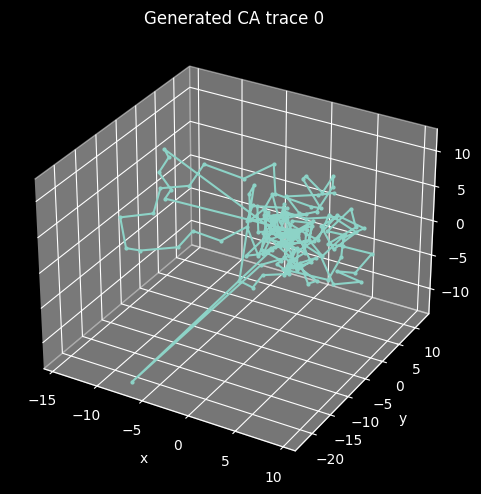

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Generated example 1
{'n_residues': 63.0, 'mean_adjacent_ca': 3.4422972202301025, 'fraction_adjacent_ca_in_band': 0.33870968222618103, 'mean_n_ca': 1.3192658424377441, 'mean_ca_c': 1.4157617092132568, 'mean_c_o': 0.9999223351478577, 'mean_c_n': 1.2547343969345093, 'radius_of_gyration': 6.6655731201171875}


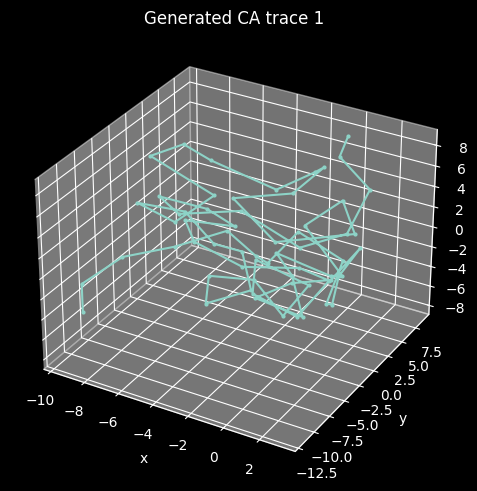

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [11]:
for index in range(min(2, sampled_coords.shape[0])):
    print(f'Generated example {index}')
    print(backbone_structure_summary(sampled_coords[index].cpu(), sample_mask[index].cpu()))
    plot_ca_trace_from_batch(sampled_coords[index].cpu(), sample_mask[index].bool().cpu(), title=f'Generated CA trace {index}')
    render_backbone_example(sampled_coords[index].cpu(), sample_mask[index].cpu(), title=f'Generated backbone {index}')

## 9. Short outcome summary

The notebook now has a visible audit trail, train-only normalization, a masked DDPM baseline, held-out evaluation, and sampled backbone structures that can be rendered directly.